# Exploratory Data Analysis: Conflict Mentions in UN General Debate Speeches (1946â€“2025)

## Research Context & Core Hypotheses (7-Page Report)
This notebook analyzes the dyadic relationship between **UN member state speeches** and **active armed conflicts**:
- **Dyad Unit**: `(speaking_country, conflict_id, year)` ($N = 438,425$)
- **Target Variable**: `has_conflict_mention` (Boolean: whether country $i$'s speech in year $t$ referenced conflict $j$)
- **Key Empirical Drivers**:
  1. **Geographic Proximity / Distance Decay (Sub-RQ 2b)**: Bilateral distance (`side_a_dist` in km).
  2. **Conflict Severity & Lethality (Sub-RQ 2a)**: Battle deaths (`deaths_estimate`) and UCDP intensity classification.
  3. **Actor Role & Stake**: Host state vs. primary combatant vs. secondary belligerent vs. observer.
  4. **Geopolitical Alignment**: Ideological divergence in UN voting (`side_a_ideals_diff`).

In [14]:
# Setup, Working Directory & Imports
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure working directory is project root
for candidate in [
    Path(r"C:\Users\stynz\Desktop\NOVSLO~2\fundamentals_of_data_science"),
    Path.cwd(),
    Path.cwd().parent
]:
    if (candidate / "data" / "final_clean.csv").exists():
        os.chdir(candidate)
        break

# Configure publication styling
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 150
sns.set_theme(style="whitegrid", font_scale=1.05)

os.makedirs('figures', exist_ok=True)

# Load final cleaned dyad dataset
df = pd.read_parquet('data/final_clean.csv')
print(f"Loaded {len(df):,} dyads across {df['year'].min()}-{df['year'].max()}.")
print(f"Baseline conflict mention rate: {df['has_conflict_mention'].mean():.2%}")

Loaded 438,425 dyads across 1946-2025.
Baseline conflict mention rate: 11.07%


## 1. Baseline Summary & Dyadic Structure

Summary statistics across the 80-year panel (1946â€“2025). Baseline probability of mentioning an active conflict is approximately **11.1%**.

In [15]:
# Summary metrics table
summary_df = pd.DataFrame({
    'Metric': [
        'Time Period',
        'Total Dyads (N)',
        'Unique Armed Conflicts',
        'Unique Member States',
        'Total Mentions (True)',
        'Baseline Mention Probability'
    ],
    'Value': [
        f"{df['year'].min()} - {df['year'].max()} (80 years)",
        f"{len(df):,}",
        f"{df['conflict_id'].nunique():,}",
        f"{df['country_code'].nunique():,}",
        f"{df['has_conflict_mention'].sum():,}",
        f"{df['has_conflict_mention'].mean():.2%}"
    ]
})
summary_df

,Metric,Value
0,Time Period,1946 - 2025 (80 years)
1,Total Dyads (N),"438,425"
2,Unique Armed Conflicts,303
3,Unique Member States,200
4,Total Mentions (True),"48,519"
5,Baseline Mention Probability,11.07%


## 2. Macro Historical Evolution: Active Wars vs. UN General Debate Discourse (RQ 1)

How has the volume of conflict discourse tracked real-world armed conflict over the 1946â€“2025 period?
- **Active Conflicts**: Total distinct UCDP conflicts active in year $t$.
- **Mentions per Speech**: Average number of active conflicts referenced in each member state's General Debate address.

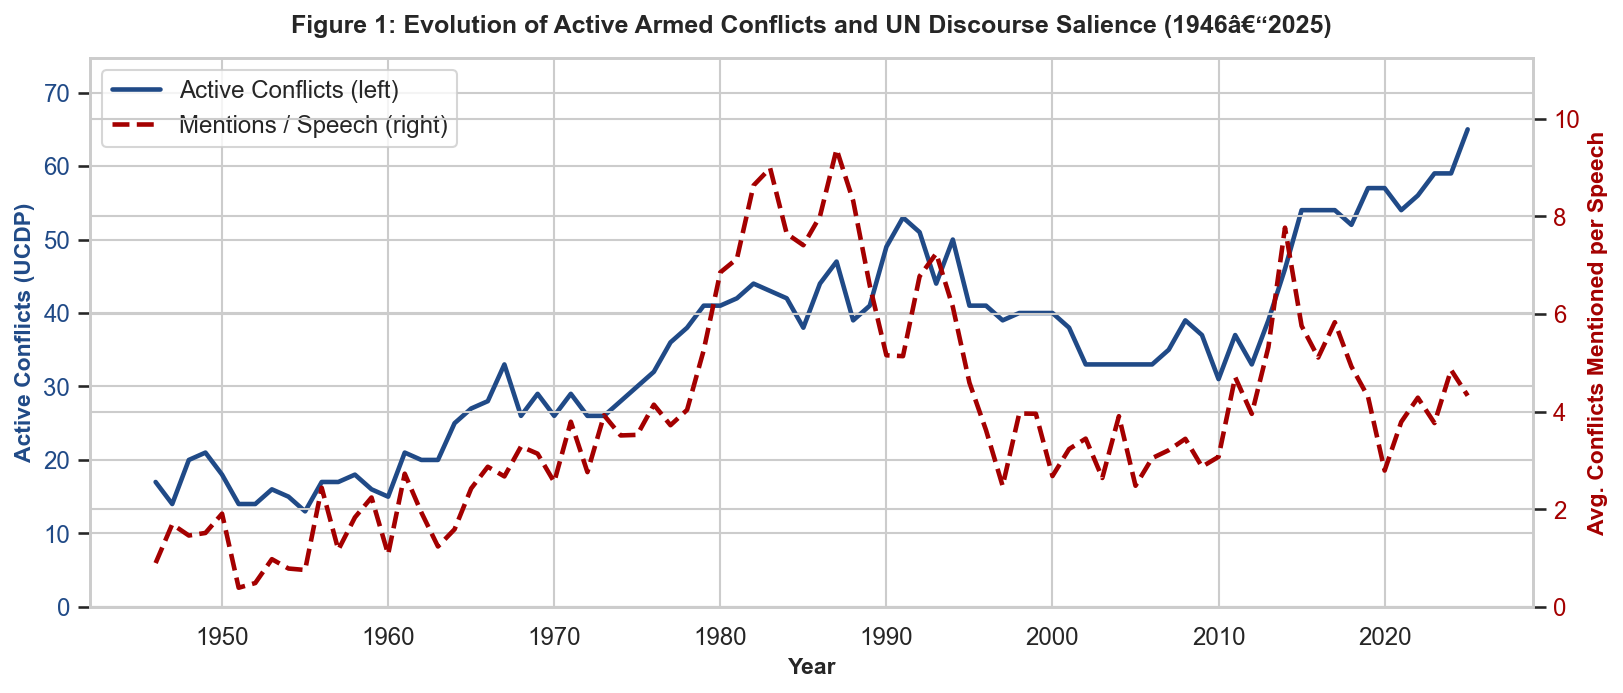

In [16]:
# Annual timeline aggregation
annual_stats = df.groupby('year').agg(
    n_active_conflicts=('conflict_id', 'nunique'),
    n_speeches=('country_code', 'nunique'),
    total_mentions=('has_conflict_mention', 'sum')
).reset_index()

annual_stats['mentions_per_speech'] = annual_stats['total_mentions'] / annual_stats['n_speeches']

# Dual-axis figure (Figure 1 in Report)
fig, ax1 = plt.subplots(figsize=(11, 4.8))

color1 = '#204a87'
ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
ax1.set_ylabel('Active Conflicts (UCDP)', color=color1, fontsize=11, fontweight='bold')
line1 = ax1.plot(annual_stats['year'], annual_stats['n_active_conflicts'], color=color1, lw=2.2, label='Active Conflicts (left)')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0, annual_stats['n_active_conflicts'].max() * 1.15)

ax2 = ax1.twinx()
color2 = '#a40000'
ax2.set_ylabel('Avg. Conflicts Mentioned per Speech', color=color2, fontsize=11, fontweight='bold')
line2 = ax2.plot(annual_stats['year'], annual_stats['mentions_per_speech'], color=color2, lw=2.2, linestyle='--', label='Mentions / Speech (right)')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, annual_stats['mentions_per_speech'].max() * 1.2)

# Legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True)

plt.title('Figure 1: Evolution of Active Armed Conflicts and UN Discourse Salience (1946â€“2025)', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('figures/fig1_annual_conflicts_and_mentions.png', dpi=300)
plt.show()

## 3. The Core Explanatory Drivers (Sub-RQ 2a & Sub-RQ 2b)


- **Panel A (Sub-RQ 2b: Geographic Proximity)**: Steep monotonic distance decay from **45.7%** ($<1,000\text{ km}$) down to **6.8%** ($>10,000\text{ km})”a **6.7-fold decrease**.
- **Panel B (Sub-RQ 2a: Conflict Lethality)**: Escalating probability from **6.9%** for skirmishes ($<25$ deaths) up to **19.4%** for wars exceeding $5,000$ battle deaths.

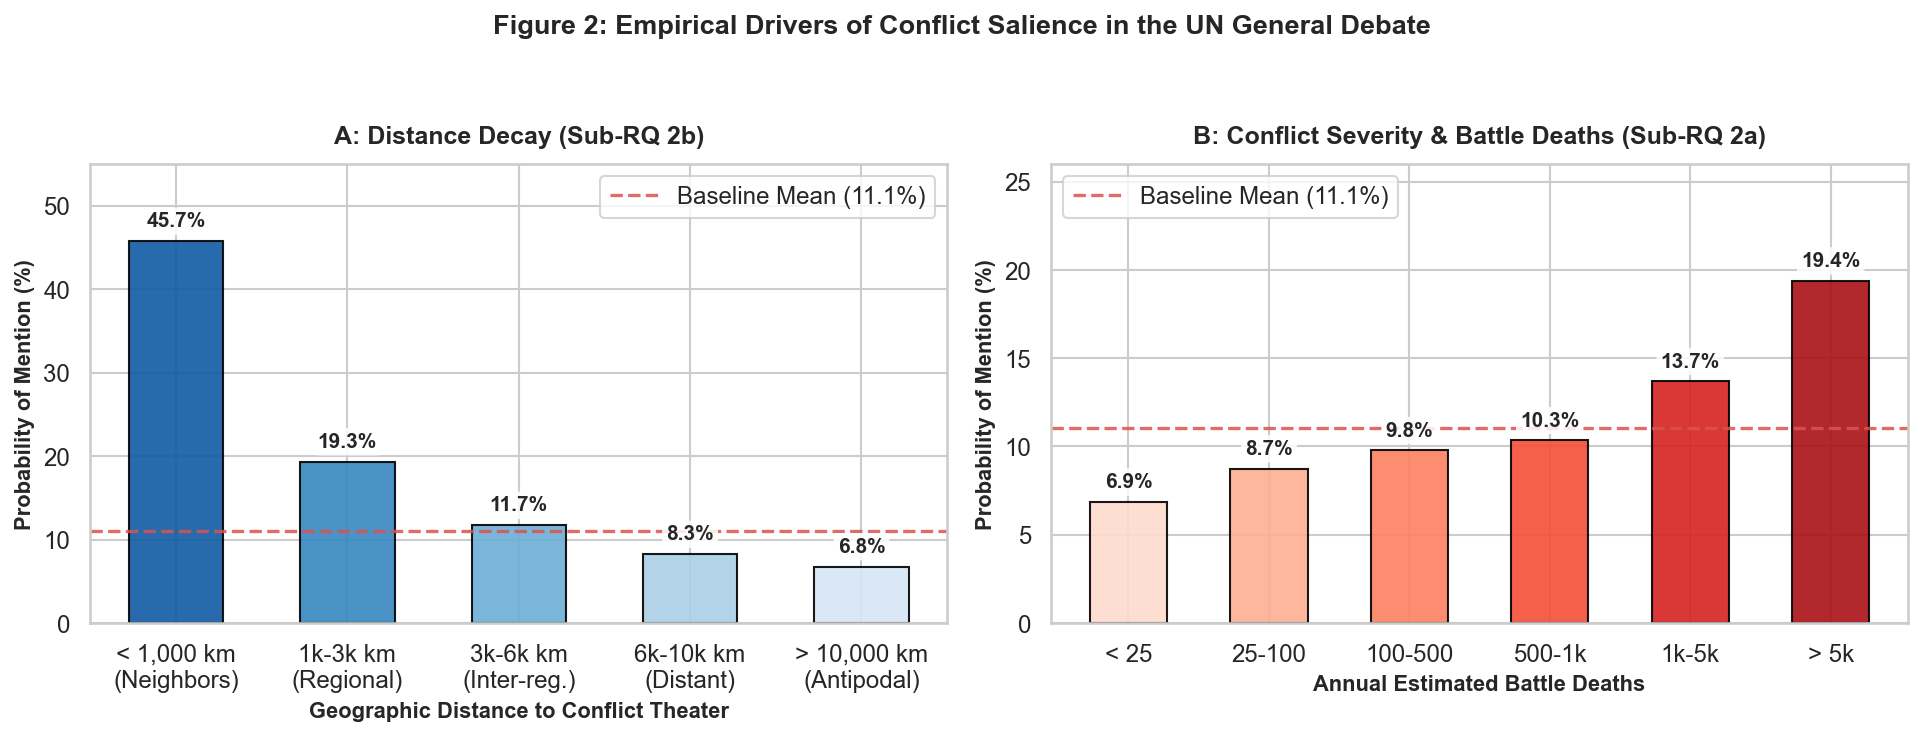

In [17]:
# 1. Distance Bins (Sub-RQ 2b)
dist_bins = [0, 1000, 3000, 6000, 10000, 30000]
dist_labels = ['< 1,000 km\n(Neighbors)', '1k-3k km\n(Regional)', '3k-6k km\n(Inter-reg.)', '6k-10k km\n(Distant)', '> 10,000 km\n(Antipodal)']
df['dist_category'] = pd.cut(df['side_a_dist'], bins=dist_bins, labels=dist_labels)

dist_summary = df.groupby('dist_category', observed=False).agg(
    rate=('has_conflict_mention', 'mean')
).reset_index()
dist_summary['rate_pct'] = dist_summary['rate'] * 100

# 2. Casualty Tiers (Sub-RQ 2a)
death_bins = [-1, 25, 100, 500, 1000, 5000, 1000000]
death_labels = ['< 25', '25-100', '100-500', '500-1k', '1k-5k', '> 5k']
df['death_tier'] = pd.cut(df['deaths_estimate'], bins=death_bins, labels=death_labels)

death_summary = df.groupby('death_tier', observed=False).agg(
    rate=('has_conflict_mention', 'mean')
).reset_index()
death_summary['rate_pct'] = death_summary['rate'] * 100

baseline_pct = df['has_conflict_mention'].mean() * 100

# --- Unified 2-Panel Figure (Figure 2 in 7-Page Report) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: Geographic Distance Decay
colors_dist = sns.color_palette('Blues_r', n_colors=len(dist_summary))
bars1 = ax1.bar(dist_summary['dist_category'], dist_summary['rate_pct'], color=colors_dist, width=0.55, edgecolor='black', alpha=0.9)
for bar in bars1:
    h = bar.get_height()
    ax1.annotate(f'{h:.1f}%', xy=(bar.get_x() + bar.get_width()/2, h),
                 xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontweight='bold', fontsize=10,
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.85))

ax1.axhline(baseline_pct, color='#d9534f', linestyle='--', lw=1.6, alpha=0.85, label=f'Baseline Mean ({baseline_pct:.1f}%)')
ax1.set_title('A: Distance Decay (Sub-RQ 2b)', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Geographic Distance to Conflict Theater', fontsize=10.5, fontweight='bold')
ax1.set_ylabel('Probability of Mention (%)', fontsize=10.5, fontweight='bold')
ax1.set_ylim(0, 55)
ax1.legend(loc='upper right', frameon=True)

# Panel B: Lethality Tiers
colors_death = sns.color_palette('Reds', n_colors=len(death_summary))
bars2 = ax2.bar(death_summary['death_tier'], death_summary['rate_pct'], color=colors_death, width=0.55, edgecolor='black', alpha=0.9)
for bar in bars2:
    h = bar.get_height()
    ax2.annotate(f'{h:.1f}%', xy=(bar.get_x() + bar.get_width()/2, h),
                 xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontweight='bold', fontsize=10,
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.85))

ax2.axhline(baseline_pct, color='#d9534f', linestyle='--', lw=1.6, alpha=0.85, label=f'Baseline Mean ({baseline_pct:.1f}%)')
ax2.set_title('B: Conflict Severity & Battle Deaths (Sub-RQ 2a)', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Annual Estimated Battle Deaths', fontsize=10.5, fontweight='bold')
ax2.set_ylabel('Probability of Mention (%)', fontsize=10.5, fontweight='bold')
ax2.set_ylim(0, 26)
ax2.legend(loc='upper left', frameon=True)

plt.suptitle('Figure 2: Empirical Drivers of Conflict Salience in the UN General Debate', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('figures/fig2_proximity_and_lethality_unified.png', dpi=300)
plt.show()

## 4. Actor Roles & Belligerency Status

How does direct belligerency influence whether a conflict is addressed?
- **Host State**: Territorial location where fighting takes place (**79.4%**)
- **Secondary Belligerent**: External troop-contributing state (**33.1%**)
- **Third-Party Observer**: Non-belligerent member state (**10.5%**)


In [18]:
def get_role(row):
    if row['conflict_host']:
        return 'Host State (Territorial Battlefield)'
    elif row['secondary_actor']:
        return 'Secondary Belligerent (Troop Contributor)'
    else:
        return 'Third-Party Observer'

df['involvement_role'] = df.apply(get_role, axis=1)

role_summary = df.groupby('involvement_role').agg(
    total_dyads=('has_conflict_mention', 'count'),
    mentions=('has_conflict_mention', 'sum'),
    mention_rate=('has_conflict_mention', 'mean')
).reindex([
    'Host State (Territorial Battlefield)',
    'Secondary Belligerent (Troop Contributor)',
    'Third-Party Observer'
]).reset_index()

role_summary['mention_rate_pct'] = role_summary['mention_rate'] * 100
role_summary

,involvement_role,total_dyads,mentions,mention_rate,mention_rate_pct
0,Host State (Territorial Battlefield),2639,2096,0.794240,79.424024
1,Secondary Belligerent (Troop Contributor),3394,1125,0.331467,33.146730
2,Third-Party Observer,432392,45298,0.104761,10.476142


## 5. Geopolitical Alignment & Ideological Divergence

Does voting divergence in the UN General Assembly (`side_a_ideals_diff`) affect speech rhetoric?
- **Ideological Allies** ($< 0.5$ difference): **8.2%** mention rate.
- **Ideological Adversaries** ($> 3.0$ difference): **28.9%** mention rate.

*Mechanism*: Member states systematically utilize the UN General Debate rostrum to air grievances, criticize geopolitical adversaries, and spotlight the conflicts of rival blocs.

In [19]:
ideal_bins = [-0.1, 0.5, 1.0, 2.0, 3.0, 7.0]
ideal_labels = ['< 0.5\n(Allies)', '0.5-1.0\n(Aligned)', '1.0-2.0\n(Moderate)', '2.0-3.0\n(Divergent)', '> 3.0\n(Rivals)']
df['ideal_category'] = pd.cut(df['side_a_ideals_diff'], bins=ideal_bins, labels=ideal_labels)

ideal_summary = df.groupby('ideal_category', observed=False).agg(
    total_dyads=('has_conflict_mention', 'count'),
    mentions=('has_conflict_mention', 'sum'),
    mention_rate=('has_conflict_mention', 'mean')
).reset_index()

ideal_summary['mention_rate_pct'] = ideal_summary['mention_rate'] * 100
ideal_summary

,ideal_category,total_dyads,mentions,mention_rate,mention_rate_pct
0,< 0.5\n(Allies),162738,13280,0.081604,8.160356
1,0.5-1.0\n(Aligned),88165,7696,0.087291,8.729088
2,1.0-2.0\n(Moderate),107643,10144,0.094237,9.423743
3,2.0-3.0\n(Divergent),37531,6415,0.170925,17.092537
4,> 3.0\n(Rivals),11919,3440,0.288615,28.861482


## 6. Global Outliers: Top 10 Most Discussed Conflicts in UN History

Which conflicts transcend geographic distance and command global attention across nearly all member states?
- **Israel / Palestine** (Conflict ID 234): **3,940 mentions** (**41.4%** across all member states).
- **South Africa Apartheid** (Conflict ID 298): **2,256 mentions** (**71.1%** mention rate during its active years).
- **Afghanistan** (Conflict ID 333): **2,490 mentions** (**29.4%** mention rate).

In [20]:
top_conflicts = df.groupby(['conflict_id', 'location']).agg(
    total_dyads=('has_conflict_mention', 'count'),
    total_mentions=('has_conflict_mention', 'sum'),
    mention_rate=('has_conflict_mention', 'mean'),
    first_year=('year', 'min'),
    last_year=('year', 'max'),
    max_deaths=('deaths_estimate', 'max')
).reset_index().sort_values('total_mentions', ascending=False).head(10)

top_conflicts['mention_rate_pct'] = top_conflicts['mention_rate'] * 100
top_conflicts['conflict_label'] = top_conflicts.apply(
    lambda r: f"{r['location']} (ID {r['conflict_id']}, {r['first_year']}-{r['last_year']})", axis=1
)

top_conflicts[['conflict_id', 'location', 'first_year', 'last_year', 'total_mentions', 'mention_rate_pct', 'max_deaths']]

,conflict_id,location,first_year,last_year,total_mentions,mention_rate_pct,max_deaths
34,234,Israel,1949,2025,3940,41.399601,26789.0
133,333,Afghanistan,1978,2025,2490,29.359745,80000.0
98,298,South Africa,1966,1989,2256,71.055118,1043.5
59,259,Iraq,1958,2025,1513,24.726262,13797.0
218,418,United States of America,2001,2019,1441,41.707670,1583.0
71,271,Iraq,1961,1996,1375,32.444549,100500.0
127,327,Angola,1975,2002,1263,30.834961,12054.0
109,309,Sudan,1971,2025,1088,13.930858,12269.0
138,338,Iran,1979,2025,1081,22.567850,2012.5
5,205,Iran,1946,2018,1058,38.528769,5083.0


## 7. Key Findings & Synthesis 

### 1. The Primacy of Geographic Proximity (Sub-RQ 2b)
- **Monotonic 6.7x Decay**: Geographic proximity is an overwhelming determinant of whether a member state addresses a conflict. Attention drops from **45.7%** for direct neighbors ($<1,000\text{ km}$) down to **6.8%** for antipodal conflicts ($>10,000\text{ km}$).
- **Regional Security Forum**: The UN General Debate is primarily leveraged as a regional forum where non-superpower nations articulate local and neighboring security threats.

### 2. Lethality vs. Salience (Sub-RQ 2a)
- **Lethality Scaling**: Probability of mention climbs monotonically from **6.9%** for low-intensity skirmishes ($<25$ deaths) to **19.4%** for catastrophic wars ($>5,000$ battle deaths).
- **Proximity Trumps Severity**: Notably, a minor skirmish occurring within $1,000\text{ km}$ ($45.7\%$) receives over **twice the attention** of a major war with $>5,000$ deaths occurring on another continent ($19.4\%$). Proximity is a significantly stronger predictor than raw casualty figures.

### 3. Diplomatic Stake and Shaming
- **Domestic Stake**: Territorial host states mention their conflict in **79.4%** of addresses, whereas non-involved observers speak about active conflicts only **10.5%** of the time.
- **Geopolitical Shaming**: Ideological adversaries ($>3.0$ difference in UN voting ideal points) are **3.5 times more likely** to address a conflict than ideological allies (**28.9% vs. 8.2%**), reflecting the rostrum's role as a platform for ideological critique.